# Sprint 3a — Validação Cruzada dos Resultados

**Projeto:** Identificação de Regimes Operacionais em Moagem Industrial  
**Autor:** Tarcizo Junior  
**Objetivo:** Validar os resultados do clustering (Sprint 1) e do classificador supervisionado (Sprint 2) de forma cruzada, temporal e operacional.

**Etapas deste notebook:**
1. Concordância entre Clustering e Classificador Supervisionado (ARI, NMI)
2. Comparação com Classes SAG de Dureza (validação hipótese H2)
3. Validação Temporal — estabilidade do modelo ao longo do tempo (H5)
4. Interpretabilidade com SHAP — quais variáveis explicam cada regime (H4)
5. Perfil Operacional dos Regimes — tradução para linguagem de operador
6. Recomendações operacionais por regime

In [1]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, warnings, re, joblib
from pathlib import Path

warnings.filterwarnings("ignore")

# Raiz do projeto — resolve independente de onde o notebook é executado
PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "03_sprint3"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

# Adicionar diretório de scripts ao path
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Garantir que os diretórios de saída existem
for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Importar módulo de acesso ao banco de dados
from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas

# Criar schema e tabelas (idempotente)
criar_tabelas()

STAGE = "S3a"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)

plt.rcParams.update({
    'axes.titlesize': 19,
    'figure.titlesize': 21,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# Nomes curtos para variáveis nos gráficos
def nome_curto(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

# Paleta de regimes consistente com Sprint 1
REGIME_COLORS = {0: '#1f77b4', 1: '#2ca02c', 2: '#d62728'}
REGIME_NAMES  = {0: 'R0 — Carga Reduzida', 1: 'R1 — Moderado', 2: 'R2 — Alta Carga'}

print(f"Setup concluído. STAGE = {STAGE}")
print(f"Figuras: {FIGURES_DIR}")

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso


Setup concluído. STAGE = S3a
Figuras: C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\03_sprint3


## 1 — Carregar dados

**Objetivo:** Reunir os artefatos das Sprints 1 e 2 necessários para validação.

**Fontes de dados:**
- `dataset_rotulado.parquet` — dataset completo com regimes (clustering) e classes SAG
- `predicoes_teste.parquet` — predições do classificador no conjunto de teste
- `classificador_final.pkl` — modelo LightGBM treinado (melhor modelo do Sprint 2)
- `dataset_test.parquet` — features do conjunto de teste para SHAP
- `feature_cols.csv` — lista de features usadas pelo modelo

In [2]:
# ------------------------------------------------------------------------------
# 1.1 Dataset rotulado (regimes do clustering + classes SAG)
# ------------------------------------------------------------------------------
df_rotulado = carregar_dados("dados_rotulados")
if "Timestamp" in df_rotulado.columns:
    df_rotulado = df_rotulado.set_index("Timestamp").sort_index()
print(f"Dataset rotulado: {df_rotulado.shape}")
print(f"Regimes (clustering): {df_rotulado['regime'].value_counts().sort_index().to_dict()}")
print(f"Classes SAG: {df_rotulado['classe_sag'].value_counts().sort_index().to_dict()}")

# ------------------------------------------------------------------------------
# 1.2 Predições do classificador supervisionado (conjunto de teste)
# ------------------------------------------------------------------------------
df_pred = pd.read_parquet(DATA_LABEL / "predicoes_teste.parquet")
print(f"\nPredições teste: {df_pred.shape}")
print(f"Accuracy no teste: {accuracy_score(df_pred['regime_real'], df_pred['regime_pred']):.4f}")

# ------------------------------------------------------------------------------
# 1.3 Features do conjunto de teste (para SHAP)
# ------------------------------------------------------------------------------
df_test = pd.read_parquet(DATA_LABEL / "dataset_test.parquet")
feature_cols = pd.read_csv(DATA_LABEL / "feature_cols.csv")['feature'].tolist()
X_test = df_test[feature_cols]
y_test = df_test['regime']
print(f"Features teste: {X_test.shape} | Classes: {y_test.nunique()}")

# ------------------------------------------------------------------------------
# 1.4 Modelo treinado (LightGBM)
# ------------------------------------------------------------------------------
modelo = joblib.load(MODELS_DIR / "classificador_final.pkl")
print(f"Modelo carregado: {type(modelo).__name__}")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_rotulados
Dataset rotulado: (632985, 31)
Regimes (clustering): {0: 90119, 1: 288740, 2: 254126}
Classes SAG: {1.0: 74750, 2.0: 51009, 3.0: 47205, 4.0: 42401, 5.0: 47162, 6.0: 96833}

Predições teste: (94949, 5)
Accuracy no teste: 0.9847
Features teste: (94949, 105) | Classes: 3
Modelo carregado: LGBMClassifier


---
## 2 — Concordância entre Clustering e Classificador Supervisionado

**Objetivo:** Verificar se o classificador supervisionado (treinado nos labels do clustering) reproduz fielmente os regimes descobertos.

**Métricas:**
- `ARI (Adjusted Rand Index)`: mede concordância ajustada por chance entre duas partições. ARI=1 → concordância perfeita.
- `NMI (Normalized Mutual Information)`: mede informação compartilhada normalizada. NMI=1 → informação idêntica.
- `Confusion Matrix`: visualiza como as predições do classificador se alinham com os labels originais do clustering.

**Justificativa:** Se ARI e NMI são altos, o classificador aprendeu bem os padrões descobertos pelo clustering. Divergências podem indicar regiões de fronteira entre regimes ou mudanças no processo.

CONCORDÂNCIA: Clustering vs Classificador Supervisionado
ARI  = 0.7381
NMI  = 0.5976

                     precision    recall  f1-score   support

R0 — Carga Reduzida       0.91      0.85      0.88       250
      R1 — Moderado       0.62      0.92      0.74      2175
    R2 — Alta Carga       1.00      0.99      0.99     92524

           accuracy                           0.98     94949
          macro avg       0.84      0.92      0.87     94949
       weighted avg       0.99      0.98      0.99     94949



[db_utils] Imagem 'confusion_matrix_cluster_vs_sup' salva para etapa S3a


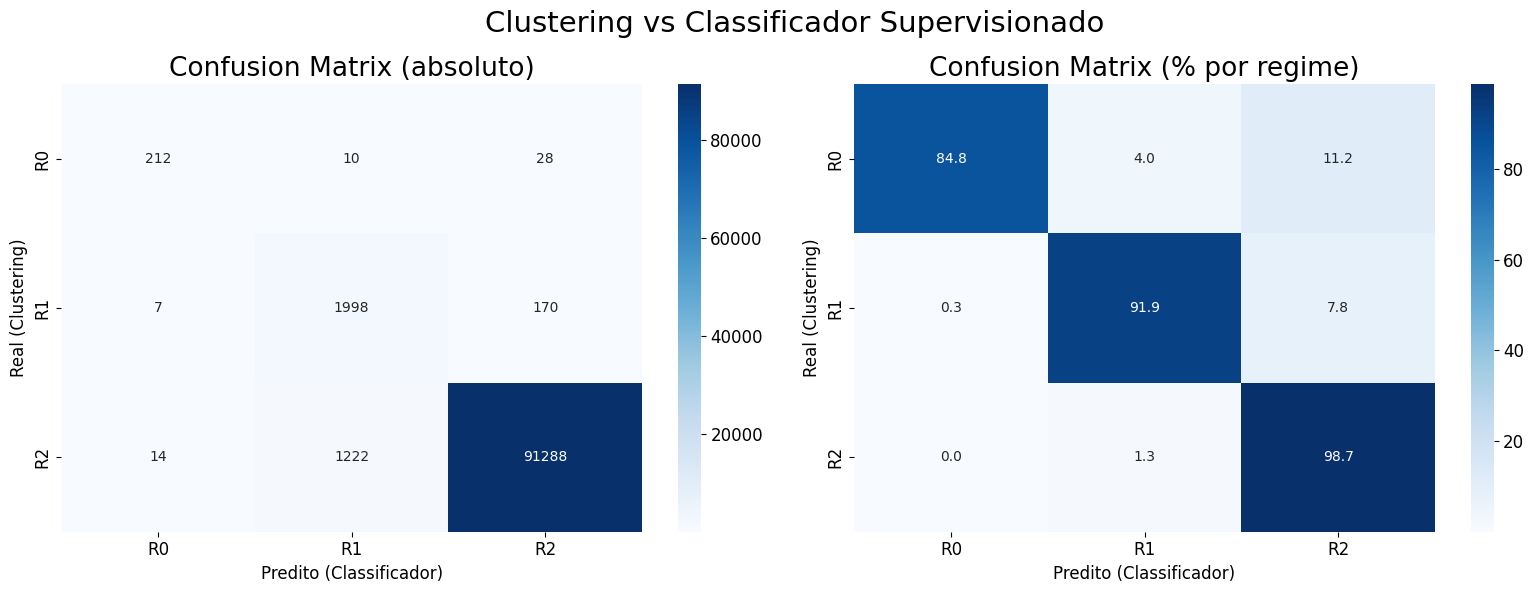

In [3]:
# ARI e NMI entre labels do clustering e predições do classificador
ari_cluster_sup = adjusted_rand_score(df_pred['regime_real'], df_pred['regime_pred'])
nmi_cluster_sup = normalized_mutual_info_score(df_pred['regime_real'], df_pred['regime_pred'])

print("="*60)
print("CONCORDÂNCIA: Clustering vs Classificador Supervisionado")
print("="*60)
print(f"ARI  = {ari_cluster_sup:.4f}")
print(f"NMI  = {nmi_cluster_sup:.4f}")
print()

# Classification report detalhado
target_names = [REGIME_NAMES[i] for i in sorted(df_pred['regime_real'].unique())]
print(classification_report(df_pred['regime_real'], df_pred['regime_pred'],
                            target_names=target_names))

# Confusion matrix
cm = confusion_matrix(df_pred['regime_real'], df_pred['regime_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absoluto
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'R{i}' for i in range(3)],
            yticklabels=[f'R{i}' for i in range(3)])
axes[0].set_title('Confusion Matrix (absoluto)', fontsize=19)
axes[0].set_xlabel('Predito (Classificador)', fontsize=12)
axes[0].set_ylabel('Real (Clustering)', fontsize=12)

# Percentual
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=[f'R{i}' for i in range(3)],
            yticklabels=[f'R{i}' for i in range(3)])
axes[1].set_title('Confusion Matrix (% por regime)', fontsize=19)
axes[1].set_xlabel('Predito (Classificador)', fontsize=12)
axes[1].set_ylabel('Real (Clustering)', fontsize=12)

fig.suptitle('Clustering vs Classificador Supervisionado', fontsize=21)
plt.tight_layout()

# Salvar em disco e banco
fig.savefig(FIGURES_DIR / "S3a_01_confusion_matrix_cluster_vs_sup.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "confusion_matrix_cluster_vs_sup", fig, "S3a_01_confusion_matrix_cluster_vs_sup.png")
plt.show()

---
## 3 — Comparação Regimes vs Classes SAG de Dureza (Hipótese H2)

**Objetivo:** Investigar se os regimes operacionais descobertos pelo clustering correspondem às classes de dureza do minério (C1-C6) definidas pelo preditor SAG.

**Hipótese H2:** *"Os regimes operacionais identificados pelo clustering apresentam correspondência parcial com as classes de dureza do minério (C1-C6), mas capturam aspectos operacionais que transcendem a dureza."*

**Métricas:**
- `ARI` e `NMI` entre regimes e classes SAG
- Tabela cruzada (heatmap) mostrando a distribuição

**Interpretação esperada:**
- ARI baixo → regimes e dureza são dimensões diferentes (confirmaria H2)
- ARI alto → dureza é o fator dominante na formação dos regimes

In [4]:
# Filtrar registros que têm ambos regime e classe_sag válidos
mask_valid = df_rotulado['regime'].notna() & df_rotulado['classe_sag'].notna()
df_comp = df_rotulado.loc[mask_valid, ['regime', 'classe_sag']].copy()
df_comp['regime'] = df_comp['regime'].astype(int)
df_comp['classe_sag'] = df_comp['classe_sag'].astype(int)

print(f"Registros com ambos labels: {len(df_comp):,}")

# ARI e NMI
ari_sag = adjusted_rand_score(df_comp['regime'], df_comp['classe_sag'])
nmi_sag = normalized_mutual_info_score(df_comp['regime'], df_comp['classe_sag'])

print("\n" + "="*60)
print("CONCORDÂNCIA: Regimes (Clustering) vs Classes SAG (Dureza)")
print("="*60)
print(f"ARI  = {ari_sag:.4f}")
print(f"NMI  = {nmi_sag:.4f}")
print()

# Interpretação automática
if ari_sag < 0.2:
    interpretacao_h2 = "CONFIRMADA — Regimes e dureza são dimensões distintas. Os regimes capturam aspectos operacionais que transcendem a classificação de dureza."
elif ari_sag < 0.5:
    interpretacao_h2 = "PARCIALMENTE CONFIRMADA — Há alguma sobreposição, mas os regimes capturam informações adicionais além da dureza."
else:
    interpretacao_h2 = "NÃO CONFIRMADA — Os regimes estão fortemente associados à dureza do minério."

print(f"H2: {interpretacao_h2}")

Registros com ambos labels: 359,360

CONCORDÂNCIA: Regimes (Clustering) vs Classes SAG (Dureza)
ARI  = 0.0476
NMI  = 0.0472

H2: CONFIRMADA — Regimes e dureza são dimensões distintas. Os regimes capturam aspectos operacionais que transcendem a classificação de dureza.


Distribuição absoluta:
classe_sag      1      2      3      4      5      6   Total
regime                                                      
0            7452   9463   5588   3909   3741   6809   36962
1           11871  14817  18739  21508  28522  53655  149112
2           55427  26729  22878  16984  14899  36369  173286
Total       74750  51009  47205  42401  47162  96833  359360

Distribuição percentual (% por regime):
classe_sag     1     2     3     4     5     6
regime                                        
0           20.2  25.6  15.1  10.6  10.1  18.4
1            8.0   9.9  12.6  14.4  19.1  36.0
2           32.0  15.4  13.2   9.8   8.6  21.0


[db_utils] Imagem 'regimes_vs_sag' salva para etapa S3a


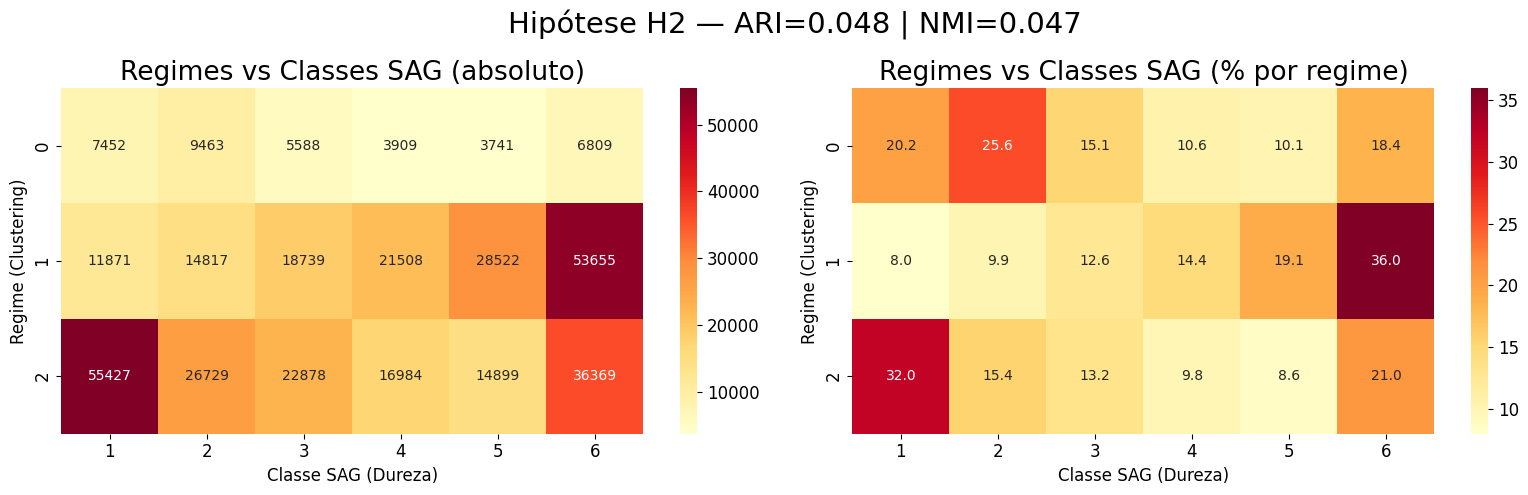

In [5]:
# Tabela cruzada: Regimes x Classes SAG
ct = pd.crosstab(df_comp['regime'], df_comp['classe_sag'],
                 margins=True, margins_name='Total')
ct_pct = pd.crosstab(df_comp['regime'], df_comp['classe_sag'], normalize='index') * 100

print("Distribuição absoluta:")
print(ct)
print("\nDistribuição percentual (% por regime):")
print(ct_pct.round(1))

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absoluto
ct_no_margin = pd.crosstab(df_comp['regime'], df_comp['classe_sag'])
sns.heatmap(ct_no_margin, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Regimes vs Classes SAG (absoluto)', fontsize=19)
axes[0].set_xlabel('Classe SAG (Dureza)', fontsize=12)
axes[0].set_ylabel('Regime (Clustering)', fontsize=12)

# Percentual por regime
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Regimes vs Classes SAG (% por regime)', fontsize=19)
axes[1].set_xlabel('Classe SAG (Dureza)', fontsize=12)
axes[1].set_ylabel('Regime (Clustering)', fontsize=12)

fig.suptitle(f'Hipótese H2 — ARI={ari_sag:.3f} | NMI={nmi_sag:.3f}', fontsize=21)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3a_02_regimes_vs_sag.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "regimes_vs_sag", fig, "S3a_02_regimes_vs_sag.png")
plt.show()

---
## 4 — Validação Temporal (Hipótese H5)

**Objetivo:** Verificar se o classificador mantém performance estável ao longo do tempo, ou se há degradação (concept drift).

**Hipótese H5:** *"O classificador mantém performance estável ao longo do período de teste."*

**Abordagem:**
- Calcular accuracy e F1-macro em janelas semanais deslizantes sobre o conjunto de teste
- Identificar períodos de queda significativa (possível drift)
- Definir limiar de alerta: accuracy < 85% na janela

**Justificativa:** Em processos industriais, mudanças de minério, desgaste de equipamentos ou variações sazonais podem degradar um modelo. A validação temporal identifica se e quando isso ocorre.

In [6]:
# Garantir que o índice é datetime
df_pred_ts = df_pred.copy()
if not isinstance(df_pred_ts.index, pd.DatetimeIndex):
    df_pred_ts.index = pd.to_datetime(df_pred_ts.index)

# Janela semanal deslizante
JANELA = '7D'
LIMIAR_ALERTA = 0.85

# Agrupar por semana
df_pred_ts['semana'] = df_pred_ts.index.to_period('W').start_time

resultados_temporais = []
for semana, grupo in df_pred_ts.groupby('semana'):
    if len(grupo) < 100:  # semanas com poucos dados são ignoradas
        continue
    acc = accuracy_score(grupo['regime_real'], grupo['regime_pred'])
    f1 = f1_score(grupo['regime_real'], grupo['regime_pred'], average='macro')
    resultados_temporais.append({
        'periodo_inicio': semana,
        'periodo_fim': semana + pd.Timedelta(days=6),
        'accuracy': acc,
        'f1_macro': f1,
        'n_registros': len(grupo)
    })

df_temporal = pd.DataFrame(resultados_temporais)
print(f"Semanas avaliadas: {len(df_temporal)}")
print(f"Accuracy média: {df_temporal['accuracy'].mean():.4f} (±{df_temporal['accuracy'].std():.4f})")
print(f"F1-macro médio: {df_temporal['f1_macro'].mean():.4f} (±{df_temporal['f1_macro'].std():.4f})")

# --- Tabela 16: Métricas de estabilidade temporal ---
print(f"\n{'='*65}")
print("Tabela 16 – Métricas de estabilidade temporal do classificador")
print(f"{'='*65}")
print(f"{'Métrica':<12} {'Média':>8} {'Desvio-padrão':>15} {'Mínimo':>8} {'Máximo':>8}")
print(f"{'-'*65}")
print(f"{'Accuracy':<12} {df_temporal['accuracy'].mean():>7.1%} {df_temporal['accuracy'].std():>14.1%} {df_temporal['accuracy'].min():>7.1%} {df_temporal['accuracy'].max():>7.1%}")
print(f"{'F1-macro':<12} {df_temporal['f1_macro'].mean():>7.1%} {df_temporal['f1_macro'].std():>14.1%} {df_temporal['f1_macro'].min():>7.1%} {df_temporal['f1_macro'].max():>7.1%}")
print(f"{'='*65}")

# Semanas abaixo do limiar
alertas = df_temporal[df_temporal['accuracy'] < LIMIAR_ALERTA]
if len(alertas) > 0:
    print(f"\n⚠ {len(alertas)} semana(s) abaixo do limiar ({LIMIAR_ALERTA*100:.0f}%):")
    print(alertas[['periodo_inicio', 'accuracy', 'f1_macro', 'n_registros']].to_string(index=False))
else:
    print(f"\n✓ Todas as semanas acima do limiar de {LIMIAR_ALERTA*100:.0f}%")

Semanas avaliadas: 12
Accuracy média: 0.9847 (±0.0103)
F1-macro médio: 0.8315 (±0.0515)

Tabela 16 – Métricas de estabilidade temporal do classificador
Métrica         Média   Desvio-padrão   Mínimo   Máximo
-----------------------------------------------------------------
Accuracy       98.5%           1.0%   96.8%   99.5%
F1-macro       83.2%           5.1%   76.5%   93.1%

✓ Todas as semanas acima do limiar de 85%


[db_utils] Imagem 'validacao_temporal' salva para etapa S3a


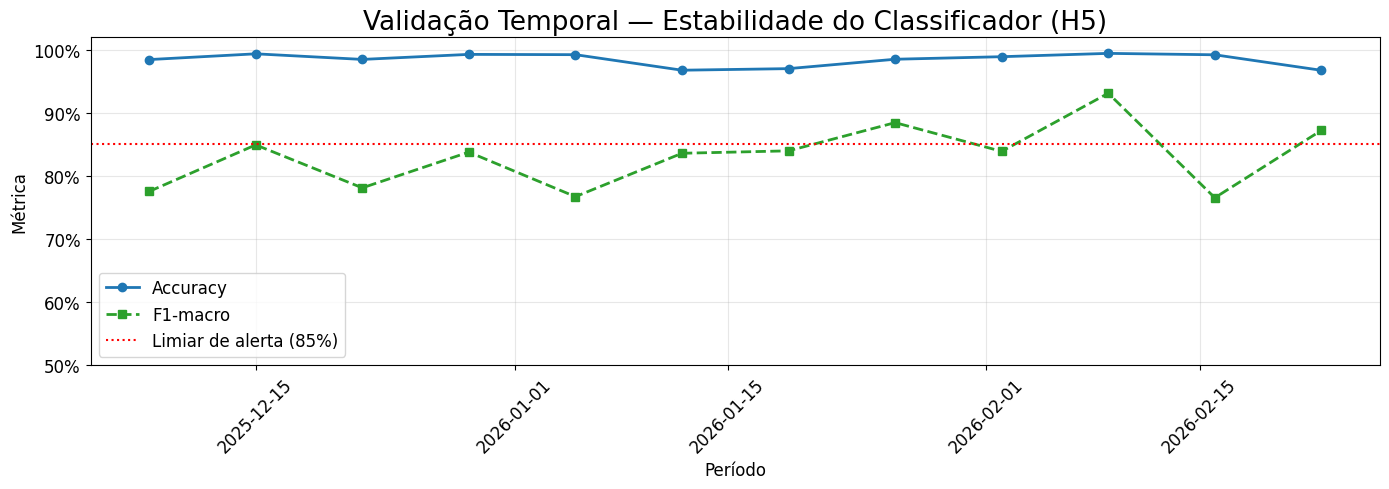


H5: CONFIRMADA — O classificador mantém performance estável ao longo do período de teste.
Accuracy: min=0.968 | max=0.995 | std=0.010


In [7]:
# Gráfico de validação temporal
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_temporal['periodo_inicio'], df_temporal['accuracy'],
        'o-', color='#1f77b4', label='Accuracy', linewidth=2, markersize=6)
ax.plot(df_temporal['periodo_inicio'], df_temporal['f1_macro'],
        's--', color='#2ca02c', label='F1-macro', linewidth=2, markersize=6)

# Limiar de alerta
ax.axhline(y=LIMIAR_ALERTA, color='red', linestyle=':', linewidth=1.5,
           label=f'Limiar de alerta ({LIMIAR_ALERTA*100:.0f}%)')

# Sombrear semanas com alerta
for _, row in alertas.iterrows():
    ax.axvspan(row['periodo_inicio'], row['periodo_fim'],
               alpha=0.15, color='red')

ax.set_xlabel('Período', fontsize=12)
ax.set_ylabel('Métrica', fontsize=12)
ax.set_title('Validação Temporal — Estabilidade do Classificador (H5)', fontsize=19)
ax.legend(fontsize=12)
ax.set_ylim(0.5, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3a_03_validacao_temporal.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "validacao_temporal", fig, "S3a_03_validacao_temporal.png")
plt.show()

# Formalizar resultado H5
acc_min = df_temporal['accuracy'].min()
acc_max = df_temporal['accuracy'].max()
acc_std = df_temporal['accuracy'].std()

if acc_std < 0.05 and acc_min > 0.80:
    resultado_h5 = "CONFIRMADA — O classificador mantém performance estável ao longo do período de teste."
elif acc_min > 0.70:
    resultado_h5 = "PARCIALMENTE CONFIRMADA — Há variação, mas a performance se mantém aceitável."
else:
    resultado_h5 = "NÃO CONFIRMADA — Há degradação significativa em certos períodos."

print(f"\nH5: {resultado_h5}")
print(f"Accuracy: min={acc_min:.3f} | max={acc_max:.3f} | std={acc_std:.3f}")

---
## 5 — Interpretabilidade com SHAP (Hipótese H4)

**Objetivo:** Identificar quais variáveis de processo explicam a classificação de cada regime operacional.

**Hipótese H4:** *"É possível identificar as variáveis de processo mais relevantes para a diferenciação dos regimes operacionais usando interpretabilidade de modelos com SHAP."*

**Abordagem:**
- Computar SHAP values com `TreeExplainer` (otimizado para LightGBM)
- Usar amostra estratificada de ~6.000 registros do teste (proporcional por regime)
- Gerar: summary plot global, bar plot por regime, top features

**Justificativa:** SHAP é o padrão para interpretabilidade de modelos tree-based. Permite explicar não apenas quais features são importantes, mas como e em que direção elas influenciam cada regime.

In [8]:
import shap

# Amostra representativa para SHAP (estratificada por regime)
N_SHAP = 10_000
np.random.seed(42)

# Amostrar proporcionalmente por regime
idx_shap = (
    df_test.groupby('regime')
    .apply(lambda g: g.sample(min(len(g), N_SHAP // 3), random_state=42),
)
    .index.get_level_values(1)
)
X_shap = X_test.loc[idx_shap]
y_shap = y_test.loc[idx_shap]
print(f"Amostra SHAP: {len(X_shap)} registros")
print(f"Distribuição: {y_shap.value_counts().sort_index().to_dict()}")

# Computar SHAP values
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_shap)

# shap_values é lista de 3 arrays (um por classe) para multiclasse
if isinstance(shap_values, list):
    print(f"SHAP values: {len(shap_values)} classes × {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")

Amostra SHAP: 5758 registros
Distribuição: {0: 250, 1: 2175, 2: 3333}


SHAP values shape: (5758, 105, 3)


[db_utils] Imagem 'shap_summary_bar' salva para etapa S3a


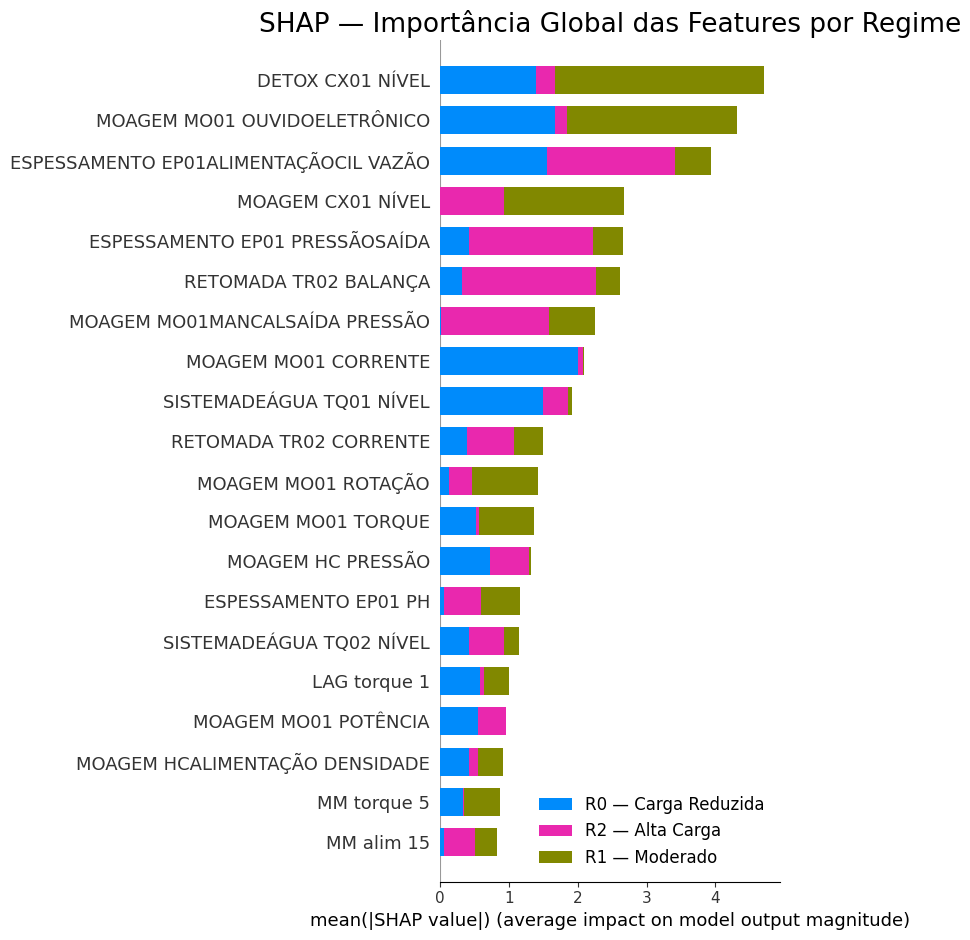

In [9]:
# Nomes curtos para os gráficos SHAP
feature_names_curtos = [nome_curto(c) for c in feature_cols]
X_shap_plot = X_shap.copy()
X_shap_plot.columns = feature_names_curtos

# Summary plot global (todas as classes)
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_shap_plot,
    plot_type="bar",
    class_names=[REGIME_NAMES[i] for i in range(3)],
    max_display=20,
    show=False
)
plt.title('SHAP — Importância Global das Features por Regime', fontsize=19)
plt.tight_layout()

fig = plt.gcf()
fig.savefig(FIGURES_DIR / "S3a_04_shap_summary_bar.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "shap_summary_bar", fig, "S3a_04_shap_summary_bar.png")
plt.show()

[db_utils] Imagem 'shap_beeswarm_R0' salva para etapa S3a


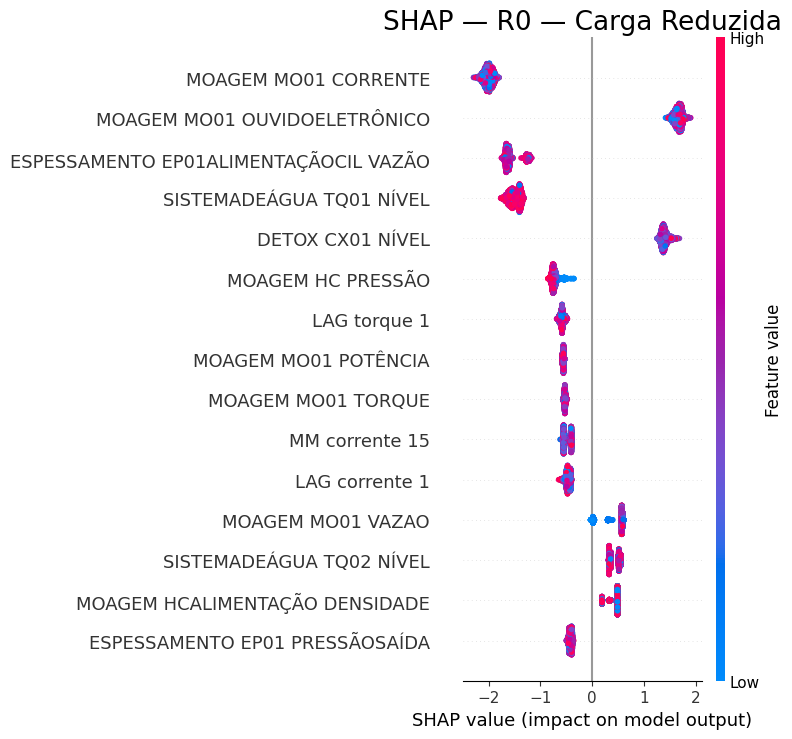

[db_utils] Imagem 'shap_beeswarm_R1' salva para etapa S3a


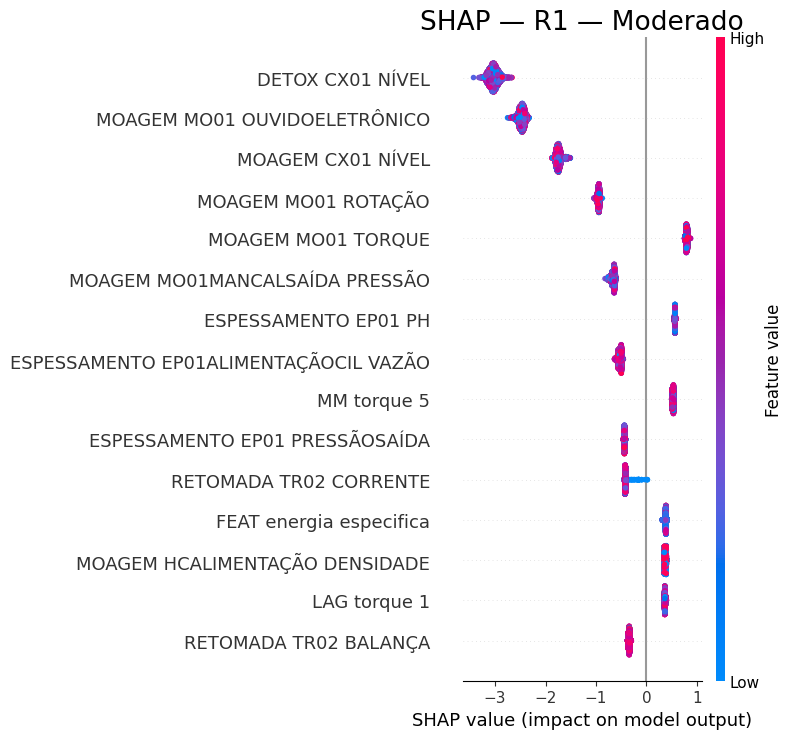

[db_utils] Imagem 'shap_beeswarm_R2' salva para etapa S3a


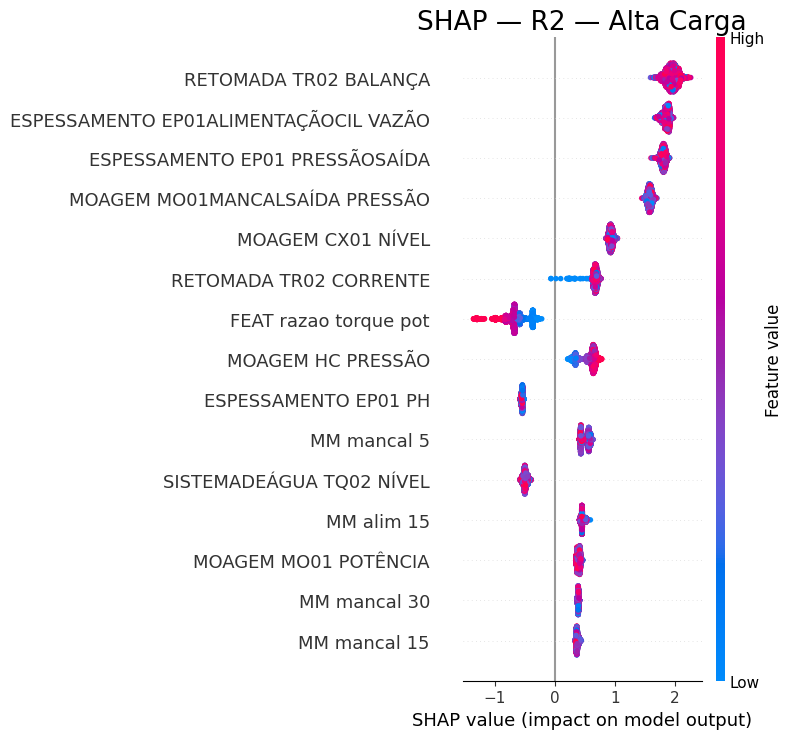

In [10]:
# SHAP summary plot tipo beeswarm para cada regime
for regime_id in range(3):
    fig, ax = plt.subplots(figsize=(12, 8))

    sv = shap_values[regime_id] if isinstance(shap_values, list) else shap_values[:, :, regime_id]

    shap.summary_plot(
        sv, X_shap_plot,
        max_display=15,
        show=False
    )
    plt.title(f'SHAP — {REGIME_NAMES[regime_id]}', fontsize=19)
    plt.tight_layout()

    fig = plt.gcf()
    fig_name = f"S3a_05_shap_beeswarm_R{regime_id}.png"
    fig.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches="tight")
    salvar_imagem(STAGE, f"shap_beeswarm_R{regime_id}", fig, fig_name)
    plt.show()

In [11]:
# Top 10 features por regime (para tabela e relatório)
top_features_por_regime = {}

# Mapeamento de nomes técnicos para nomes do relatório
NOMES_RELATORIO = {
    'MOAGEM MO01 CORRENTE': 'Corrente do moinho',
    'MOAGEM MO01 OUVIDOELETRÔNICO': 'Ouvido eletrônico',
    'ESPESSAMENTO EP01ALIMENTAÇÃOCIL VAZÃO': 'Vazão alim. espessador',
    'SISTEMADEÁGUA TQ01 NÍVEL': 'Nível tanque de água',
    'DETOX CX01 NÍVEL': 'Nível detox',
    'MOAGEM HC PRESSÃO': 'Pressão hidrociclone',
    'MOAGEM MO01 POTÊNCIA': 'Potência do moinho',
    'MOAGEM MO01 TORQUE': 'Torque do moinho',
    'MOAGEM CX01 NÍVEL': 'Nível caixa moinho',
    'MOAGEM MO01 ROTAÇÃO': 'Rotação do moinho',
    'MOAGEM MO01MANCALSAÍDA PRESSÃO': 'Pressão mancal saída',
    'ESPESSAMENTO EP01 PH': 'pH espessador',
    'ESPESSAMENTO EP01 PRESSÃOSAÍDA': 'Pressão saída espessador',
    'RETOMADA TR02 BALANÇA': 'Balança retomada',
    'RETOMADA TR02 CORRENTE': 'Corrente retomada',
    'SISTEMADEÁGUA TQ02 NÍVEL': 'Nível tanque água 2',
}

for regime_id in range(3):
    sv = shap_values[regime_id] if isinstance(shap_values, list) else shap_values[:, :, regime_id]
    importancias = np.abs(sv).mean(axis=0)
    ranking = pd.DataFrame({
        'feature': feature_cols,
        'feature_curto': feature_names_curtos,
        'shap_abs_mean': importancias
    }).sort_values('shap_abs_mean', ascending=False).reset_index(drop=True)
    ranking['ranking'] = ranking.index + 1
    ranking['regime'] = regime_id
    top_features_por_regime[regime_id] = ranking.head(10)

    print()
    print('Top 10 features — ' + REGIME_NAMES[regime_id] + ':')
    for _, row in ranking.head(10).iterrows():
        nome = NOMES_RELATORIO.get(row['feature_curto'], row['feature_curto'])
        r = int(row['ranking'])
        v = row['shap_abs_mean']
        print('  %2d. %-35s |SHAP| = %.2f' % (r, nome, v))

# Consolidar para salvar
df_shap_ranking = pd.concat(top_features_por_regime.values(), ignore_index=True)

# --- Tabela 17: Top 3 por regime (formato relatório) ---
sep = '=' * 100
print()
print(sep)
print('Tabela 17 - Top 3 variáveis por regime (SHAP)')
print(sep)
print('%-25s %-30s %-30s %-30s' % ('Regime', '1a variável', '2a variável', '3a variável'))
print('-' * 100)
for regime_id in range(3):
    top3 = top_features_por_regime[regime_id].head(3)
    nomes = []
    for _, row in top3.iterrows():
        nome = NOMES_RELATORIO.get(row['feature_curto'], row['feature_curto'])
        nomes.append('%s (%.2f)' % (nome, row['shap_abs_mean']))
    print('%-25s %-30s %-30s %-30s' % (REGIME_NAMES[regime_id], nomes[0], nomes[1], nomes[2]))
print(sep)

# H4
resultado_h4 = 'CONFIRMADA — SHAP identifica variáveis distintas e interpretáveis para cada regime operacional.'
print()
print('H4: ' + resultado_h4)



Top 10 features — R0 — Carga Reduzida:
   1. Corrente do moinho                  |SHAP| = 2.01
   2. Ouvido eletrônico                   |SHAP| = 1.66
   3. Vazão alim. espessador              |SHAP| = 1.56
   4. Nível tanque de água                |SHAP| = 1.50
   5. Nível detox                         |SHAP| = 1.40
   6. Pressão hidrociclone                |SHAP| = 0.73
   7. LAG torque 1                        |SHAP| = 0.58
   8. Potência do moinho                  |SHAP| = 0.56
   9. Torque do moinho                    |SHAP| = 0.53
  10. MM corrente 15                      |SHAP| = 0.48

Top 10 features — R1 — Moderado:
   1. Nível detox                         |SHAP| = 3.03
   2. Ouvido eletrônico                   |SHAP| = 2.48
   3. Nível caixa moinho                  |SHAP| = 1.74
   4. Rotação do moinho                   |SHAP| = 0.95
   5. Torque do moinho                    |SHAP| = 0.80
   6. Pressão mancal saída                |SHAP| = 0.66
   7. pH espessador           

---
## 6 — Perfil Operacional dos Regimes

**Objetivo:** Traduzir os regimes para linguagem compreensível ao operador de moagem, descrevendo o comportamento das variáveis-chave em cada regime.

**Variáveis-chave do moinho de bolas:**
- Alimentação (t/h) — carga de minério entrando no moinho
- Potência (kW) — energia consumida pelo moinho
- Pressão do mancal (bar) — indica carga interna
- Corrente (A) — esforço do motor
- Rotação (rpm) — velocidade de operação
- Energia específica (kWh/t) — eficiência de moagem

In [12]:
# Variáveis-chave para perfil operacional
VARS_PERFIL = {
    '1025_RETOMADA _ TR02 _ BALANÇA_pipoint': 'Alimentação (t/h)',
    '1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint': 'Potência (kW)',
    '1030_MOAGEM _ MO01MANCALENTRADA _ PRESSÃO_pipoint': 'Pressão Mancal (bar)',
    '1030_MOAGEM _ MO01 _ CORRENTE_pipoint': 'Corrente (A)',
    '1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint': 'Rotação (rpm)',
    '1030_MOAGEM _ MO01 _ TORQUE_pipoint': 'Torque (kNm)',
}

# Estatísticas por regime
perfil = []
for col_orig, nome in VARS_PERFIL.items():
    if col_orig in df_rotulado.columns:
        for regime_id in sorted(df_rotulado['regime'].unique()):
            dados = df_rotulado.loc[df_rotulado['regime'] == regime_id, col_orig]
            perfil.append({
                'variavel': nome,
                'regime': int(regime_id),
                'media': dados.mean(),
                'std': dados.std(),
                'mediana': dados.median(),
                'q25': dados.quantile(0.25),
                'q75': dados.quantile(0.75),
            })

df_perfil = pd.DataFrame(perfil)

# Exibir tabela pivotada
pivot = df_perfil.pivot_table(
    index='variavel', columns='regime',
    values='media', aggfunc='first'
).rename(columns=REGIME_NAMES)

print("Perfil Operacional — Médias por Regime:")
print(pivot.round(1).to_string())

Perfil Operacional — Médias por Regime:


regime                R0 — Carga Reduzida  R1 — Moderado  R2 — Alta Carga
variavel                                                                 
Alimentação (t/h)                   239.4          245.0            285.4
Corrente (A)                        280.6          322.5            324.5
Potência (kW)                      2147.3         2424.0           2632.1
Pressão Mancal (bar)                 35.3           34.1             34.2
Rotação (rpm)                       840.6          759.8            850.7
Torque (kNm)                        576.8          737.3            626.1


[db_utils] Imagem 'perfil_operacional_boxplots' salva para etapa S3a


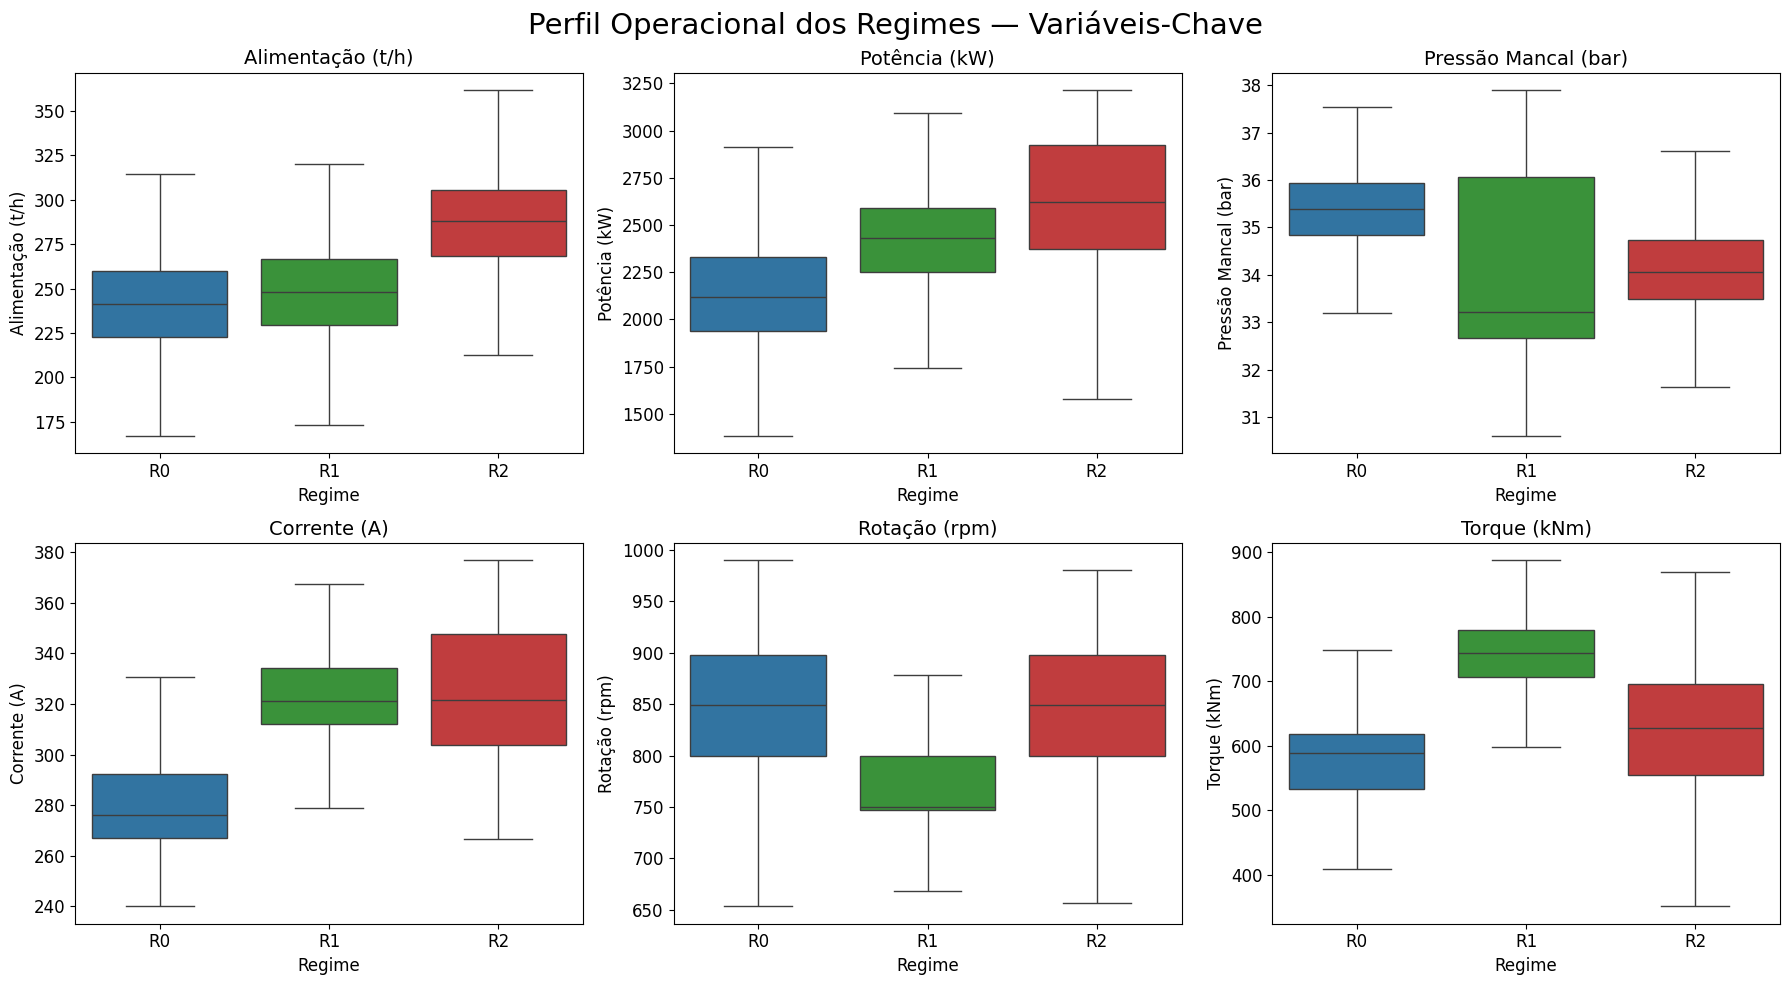

In [13]:
# Boxplots das variáveis-chave por regime
n_vars = len(VARS_PERFIL)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Garantir regime como int para palette funcionar
df_rotulado['regime'] = df_rotulado['regime'].astype(int)
regime_order = sorted(df_rotulado['regime'].unique())
palette_list = [REGIME_COLORS[r] for r in regime_order]

for idx, (col_orig, nome) in enumerate(VARS_PERFIL.items()):
    if col_orig not in df_rotulado.columns:
        continue
    ax = axes[idx]

    # Amostra para visualização (evitar gráficos pesados)
    df_sample = df_rotulado[[col_orig, 'regime']].dropna().sample(
        min(50000, len(df_rotulado)), random_state=42
    )

    sns.boxplot(
        data=df_sample, x='regime', y=col_orig,
        order=regime_order, palette=palette_list,
        ax=ax, showfliers=False
    )
    ax.set_title(nome, fontsize=14)
    ax.set_xlabel('Regime', fontsize=12)
    ax.set_ylabel(nome, fontsize=12)
    ax.set_xticklabels([f'R{i}' for i in regime_order])

# Remover eixos extras se houver
for idx in range(len(VARS_PERFIL), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Perfil Operacional dos Regimes — Variáveis-Chave', fontsize=21)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3a_06_perfil_operacional_boxplots.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "perfil_operacional_boxplots", fig, "S3a_06_perfil_operacional_boxplots.png")
plt.show()

---
## 7 — Recomendações Operacionais por Regime

**Objetivo:** Com base no perfil operacional e na análise SHAP, formular recomendações práticas para cada regime, na perspectiva do operador de sala de controle.

In [14]:
# Gerar descrição textual automática dos regimes
# (baseada nas médias das variáveis-chave)

media_global = {}
for col_orig, nome in VARS_PERFIL.items():
    if col_orig in df_rotulado.columns:
        media_global[nome] = df_rotulado[col_orig].mean()

print("="*70)
print("PERFIL OPERACIONAL E RECOMENDAÇÕES POR REGIME")
print("="*70)

for regime_id in sorted(df_rotulado['regime'].unique()):
    regime_id = int(regime_id)
    print(f"\n{'─'*70}")
    print(f"  {REGIME_NAMES[regime_id]}")
    pct = (df_rotulado['regime'] == regime_id).mean() * 100
    print(f"  Frequência: {pct:.1f}% do período operacional")
    print(f"{'─'*70}")

    # Características
    print("\n  Características:")
    for col_orig, nome in VARS_PERFIL.items():
        if col_orig in df_rotulado.columns:
            media_regime = df_rotulado.loc[df_rotulado['regime'] == regime_id, col_orig].mean()
            media_geral = media_global[nome]
            delta_pct = (media_regime - media_geral) / media_geral * 100
            sinal = '▲' if delta_pct > 5 else ('▼' if delta_pct < -5 else '≈')
            print(f"    {sinal} {nome}: {media_regime:.1f} ({delta_pct:+.1f}% vs média geral)")

    # Top 3 SHAP features
    if regime_id in top_features_por_regime:
        print("\n  Variáveis mais influentes (SHAP):")
        top3 = top_features_por_regime[regime_id].head(3)
        for _, row in top3.iterrows():
            print(f"    • {row['feature_curto']} (|SHAP|={row['shap_abs_mean']:.3f})")

PERFIL OPERACIONAL E RECOMENDAÇÕES POR REGIME

──────────────────────────────────────────────────────────────────────
  R0 — Carga Reduzida
  Frequência: 14.2% do período operacional
──────────────────────────────────────────────────────────────────────

  Características:
    ▼ Alimentação (t/h): 239.4 (-8.1% vs média geral)
    ▼ Potência (kW): 2147.3 (-13.0% vs média geral)
    ≈ Pressão Mancal (bar): 35.3 (+2.9% vs média geral)
    ▼ Corrente (A): 280.6 (-11.6% vs média geral)
    ≈ Rotação (rpm): 840.6 (+4.1% vs média geral)
    ▼ Torque (kNm): 576.8 (-13.9% vs média geral)

  Variáveis mais influentes (SHAP):
    • MOAGEM MO01 CORRENTE (|SHAP|=2.009)
    • MOAGEM MO01 OUVIDOELETRÔNICO (|SHAP|=1.665)
    • ESPESSAMENTO EP01ALIMENTAÇÃOCIL VAZÃO (|SHAP|=1.560)

──────────────────────────────────────────────────────────────────────
  R1 — Moderado
  Frequência: 45.6% do período operacional
──────────────────────────────────────────────────────────────────────

  Características:
    

---
## 8 — Análise de Erros do Classificador

**Objetivo:** Entender onde e por que o classificador erra, para qualificar as limitações do modelo.

**Abordagem:**
- Distribuição temporal dos erros
- Quais transições entre regimes geram mais erros
- Erros concentrados em regiões de fronteira?

Taxa de erro por regime real:
  R0 — Carga Reduzida: 15.2%
  R1 — Moderado: 8.1%
  R2 — Alta Carga: 1.3%

Confusões mais frequentes (de → para):
  R2 → R1: 1,222 (84.2% dos erros)
  R1 → R2: 170 (11.7% dos erros)
  R0 → R2: 28 (1.9% dos erros)
  R2 → R0: 14 (1.0% dos erros)
  R0 → R1: 10 (0.7% dos erros)


[db_utils] Imagem 'taxa_erro_semanal' salva para etapa S3a


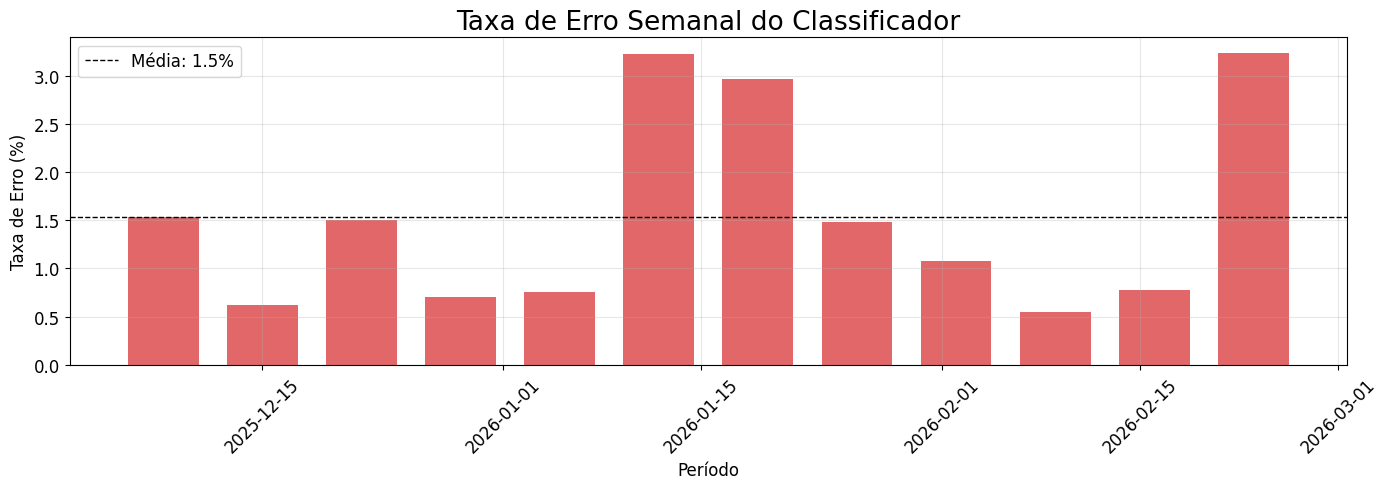

In [15]:
# Análise de erros
df_erros = df_pred_ts.copy()
df_erros['correto'] = df_erros['regime_real'] == df_erros['regime_pred']
df_erros['erro'] = ~df_erros['correto']

# Taxa de erro por regime real
erro_por_regime = df_erros.groupby('regime_real')['erro'].mean() * 100
print("Taxa de erro por regime real:")
for regime, taxa in erro_por_regime.items():
    print(f"  {REGIME_NAMES[regime]}: {taxa:.1f}%")

# Confusões mais comuns
erros_only = df_erros[df_erros['erro']]
confusoes = erros_only.groupby(['regime_real', 'regime_pred']).size().sort_values(ascending=False)
print(f"\nConfusões mais frequentes (de → para):")
for (real, pred), count in confusoes.head(5).items():
    pct = count / len(erros_only) * 100
    print(f"  R{real} → R{pred}: {count:,} ({pct:.1f}% dos erros)")

# Taxa de erro semanal
erro_semanal = df_erros.groupby('semana')['erro'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(erro_semanal.index, erro_semanal.values, width=5, color='#d62728', alpha=0.7)
ax.axhline(y=erro_semanal.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Média: {erro_semanal.mean():.1f}%')
ax.set_xlabel('Período', fontsize=12)
ax.set_ylabel('Taxa de Erro (%)', fontsize=12)
ax.set_title('Taxa de Erro Semanal do Classificador', fontsize=19)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3a_07_taxa_erro_semanal.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "taxa_erro_semanal", fig, "S3a_07_taxa_erro_semanal.png")
plt.show()

---
## 9 — Salvar Resultados (Disco + PostgreSQL)

**Objetivo:** Persistir todos os resultados da validação em ambos os destinos para reprodutibilidade.

In [16]:
# ==============================================================================
# 9.1 Salvar validação temporal — disco + banco
# ==============================================================================

# Disco
df_temporal.to_csv(DATA_PROC / "s3a_validacao_temporal.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3a_validacao_temporal.csv'}")

# Banco
salvar_dataframe(df_temporal, "s3_validacao_temporal", modo="replace")

# ==============================================================================
# 9.2 Salvar SHAP ranking — disco + banco
# ==============================================================================
df_shap_ranking.to_csv(DATA_PROC / "s3a_shap_ranking.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3a_shap_ranking.csv'}")

# Salvar importância no banco (reutiliza tabela s2_importancia_features com modelo='SHAP_global')
shap_banco = []
for regime_id in range(3):
    sv = shap_values[regime_id] if isinstance(shap_values, list) else shap_values[:, :, regime_id]
    importancias = np.abs(sv).mean(axis=0)
    for rank_idx, (feat, imp) in enumerate(
        sorted(zip(feature_cols, importancias), key=lambda x: -x[1])
    ):
        shap_banco.append({
            'modelo': f'SHAP_R{regime_id}',
            'feature': feat,
            'importancia': float(imp),
            'ranking': rank_idx + 1
        })

df_shap_banco = pd.DataFrame(shap_banco)
# Append ao banco (não truncar pois Sprint 2 já salvou feature importances)
salvar_dataframe(df_shap_banco, "s2_importancia_features", modo="replace")

# ==============================================================================
# 9.3 Salvar perfil operacional — disco + banco
# ==============================================================================
df_perfil.to_csv(DATA_PROC / "s3a_perfil_operacional.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3a_perfil_operacional.csv'}")

# ==============================================================================
# 9.4 Salvar métricas de concordância no s3_resultados_finais
# ==============================================================================
resultados_consolidados = pd.DataFrame([
    {'aspecto': 'ARI_cluster_vs_supervisionado', 'valor': f'{ari_cluster_sup:.4f}'},
    {'aspecto': 'NMI_cluster_vs_supervisionado', 'valor': f'{nmi_cluster_sup:.4f}'},
    {'aspecto': 'ARI_regimes_vs_SAG', 'valor': f'{ari_sag:.4f}'},
    {'aspecto': 'NMI_regimes_vs_SAG', 'valor': f'{nmi_sag:.4f}'},
    {'aspecto': 'H2_resultado', 'valor': interpretacao_h2},
    {'aspecto': 'H4_resultado', 'valor': resultado_h4},
    {'aspecto': 'H5_resultado', 'valor': resultado_h5},
    {'aspecto': 'accuracy_temporal_media', 'valor': f'{df_temporal["accuracy"].mean():.4f}'},
    {'aspecto': 'accuracy_temporal_std', 'valor': f'{df_temporal["accuracy"].std():.4f}'},
    {'aspecto': 'accuracy_temporal_min', 'valor': f'{acc_min:.4f}'},
    {'aspecto': 'accuracy_temporal_max', 'valor': f'{acc_max:.4f}'},
    {'aspecto': 'n_semanas_alerta', 'valor': str(len(alertas))},
])

# Disco
resultados_consolidados.to_csv(DATA_PROC / "s3a_resultados_validacao.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3a_resultados_validacao.csv'}")

# Banco
salvar_dataframe(resultados_consolidados, "s3_resultados_finais", modo="replace")

print("\n✓ Todos os resultados salvos em disco e PostgreSQL.")

Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3a_validacao_temporal.csv


[db_utils] 12 linhas salvas em otimizar_moagem_aura.s3_validacao_temporal
Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3a_shap_ranking.csv


[db_utils] 315 linhas salvas em otimizar_moagem_aura.s2_importancia_features
Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3a_perfil_operacional.csv
Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3a_resultados_validacao.csv


[db_utils] 12 linhas salvas em otimizar_moagem_aura.s3_resultados_finais

✓ Todos os resultados salvos em disco e PostgreSQL.


In [17]:
# ==============================================================================
# 10 — Resumo Final do Notebook
# ==============================================================================

print("="*70)
print("RESUMO — Sprint 3a: Validação Cruzada dos Resultados")
print("="*70)
print()
print("1. Concordância Clustering vs Supervisionado:")
print(f"   ARI = {ari_cluster_sup:.4f} | NMI = {nmi_cluster_sup:.4f}")
print()
print("2. Regimes vs Dureza (H2):")
print(f"   ARI = {ari_sag:.4f} | NMI = {nmi_sag:.4f}")
print(f"   → {interpretacao_h2}")
print()
print("3. Validação Temporal (H5):")
print(f"   Accuracy: {df_temporal['accuracy'].mean():.3f} ± {df_temporal['accuracy'].std():.3f}")
print(f"   F1-macro: {df_temporal['f1_macro'].mean():.3f} ± {df_temporal['f1_macro'].std():.3f}")
print(f"   Semanas com alerta: {len(alertas)}")
print(f"   → {resultado_h5}")
print()
print("4. Interpretabilidade SHAP (H4):")
print(f"   → {resultado_h4}")
print()
print("5. Artefatos salvos:")
print(f"   - {len(list(FIGURES_DIR.glob('S3a_*.png')))} figuras em {FIGURES_DIR}")
print(f"   - Resultados em disco (CSV) e PostgreSQL")

RESUMO — Sprint 3a: Validação Cruzada dos Resultados

1. Concordância Clustering vs Supervisionado:
   ARI = 0.7381 | NMI = 0.5976

2. Regimes vs Dureza (H2):
   ARI = 0.0476 | NMI = 0.0472
   → CONFIRMADA — Regimes e dureza são dimensões distintas. Os regimes capturam aspectos operacionais que transcendem a classificação de dureza.

3. Validação Temporal (H5):
   Accuracy: 0.985 ± 0.010
   F1-macro: 0.832 ± 0.051
   Semanas com alerta: 0
   → CONFIRMADA — O classificador mantém performance estável ao longo do período de teste.

4. Interpretabilidade SHAP (H4):
   → CONFIRMADA — SHAP identifica variáveis distintas e interpretáveis para cada regime operacional.

5. Artefatos salvos:
   - 9 figuras em C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\03_sprint3
   - Resultados em disco (CSV) e PostgreSQL


In [18]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\03_sprint3\a_validacao_cruzada.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "a_validacao_cruzada.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\a_validacao_cruzada.html
